In [13]:
#importing 
import numpy as np
import json
import pickle
import shutil
import os
import gc
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset as HFDataset
import evaluate
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)

In [15]:
# ══════════════════════════════════════════════════════════════
# LOAD DATA
# ══════════════════════════════════════════════════════════════
syn_train  = pd.read_csv("../data/processed/syn_train.csv")
syn_val    = pd.read_csv("../data/processed/syn_val.csv")
syn_test   = pd.read_csv("../data/processed/syn_test.csv")

real_train = pd.read_csv("../data/processed/real_train.csv")
real_val   = pd.read_csv("../data/processed/real_val.csv")
real_test  = pd.read_csv("../data/processed/real_test.csv")

print(f"\n✅ Data loaded!")
print(f"   Syn  train/val/test : {len(syn_train)}/{len(syn_val)}/{len(syn_test)}")
print(f"   Real train/val/test : {len(real_train)}/{len(real_val)}/{len(real_test)}")


✅ Data loaded!
   Syn  train/val/test : 3579/447/448
   Real train/val/test : 1132/378/378


In [16]:
# ══════════════════════════════════════════════════════════════
# METRICS
# ══════════════════════════════════════════════════════════════
f1_metric  = evaluate.load("f1")
acc_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds          = np.argmax(logits, axis=1)
    return {
        "f1": f1_metric.compute(
            predictions=preds,
            references=labels,
            average="weighted"
        )["f1"],
        "accuracy": acc_metric.compute(
            predictions=preds,
            references=labels
        )["accuracy"],
    }

# ══════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════
def to_hf_dataset(df):
    return HFDataset.from_dict({
        "review_text": df["review_text"].tolist(),
        "label":       df["label"].astype(int).tolist(),
    })

def evaluate_transformer(trainer, dataset, model_name,
                          phase, label_names=["genuine","fake"]):
    """Full evaluation with all visualizations"""

    predictions = trainer.predict(dataset)
    logits      = predictions.predictions
    labels      = predictions.label_ids
    probs       = torch.softmax(
        torch.tensor(logits), dim=1
    ).numpy()
    preds       = np.argmax(logits, axis=1)
    fake_probs  = probs[:, 1]

    title = f"{model_name} — {phase}"

    # Classification report
    print(f"\n{'='*50}")
    print(f"  {title} — Classification Report")
    print(f"{'='*50}")
    print(classification_report(
        labels, preds, target_names=label_names
    ))

    report = classification_report(
        labels, preds,
        target_names=label_names,
        output_dict=True
    )

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    # ── Confusion Matrix ──────────────────────────────────────
    cm = confusion_matrix(labels, preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=label_names,
        yticklabels=label_names,
        ax=axes[0, 0]
    )
    axes[0, 0].set_title("Confusion Matrix")
    axes[0, 0].set_ylabel("Actual")
    axes[0, 0].set_xlabel("Predicted")

    # ── Per-class Metrics ─────────────────────────────────────
    metrics     = ["precision", "recall", "f1-score"]
    genuine_val = [report["genuine"][m] for m in metrics]
    fake_val    = [report["fake"][m]    for m in metrics]
    x     = np.arange(len(metrics))
    width = 0.35
    axes[0, 1].bar(x - width/2, genuine_val, width,
                   label="Genuine", color="#4C72B0")
    axes[0, 1].bar(x + width/2, fake_val,    width,
                   label="Fake",    color="#DD8452")
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(metrics)
    axes[0, 1].set_ylim(0, 1.1)
    axes[0, 1].set_title("Per-class Metrics")
    axes[0, 1].legend()
    axes[0, 1].set_ylabel("Score")
    for i, (g, f) in enumerate(zip(genuine_val, fake_val)):
        axes[0, 1].text(i - width/2, g + 0.02,
                        f"{g:.2f}", ha="center", fontsize=9)
        axes[0, 1].text(i + width/2, f + 0.02,
                        f"{f:.2f}", ha="center", fontsize=9)

    # ── ROC Curve ─────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(labels, fake_probs)
    roc_auc     = auc(fpr, tpr)
    axes[1, 0].plot(fpr, tpr, color="#2196F3", lw=2,
                    label=f"AUC = {roc_auc:.4f}")
    axes[1, 0].plot([0,1], [0,1], "k--", lw=1)
    axes[1, 0].set_xlim([0, 1])
    axes[1, 0].set_ylim([0, 1.05])
    axes[1, 0].set_xlabel("False Positive Rate")
    axes[1, 0].set_ylabel("True Positive Rate")
    axes[1, 0].set_title("ROC Curve")
    axes[1, 0].legend(loc="lower right")
    axes[1, 0].fill_between(fpr, tpr, alpha=0.1, color="#2196F3")

    # ── Precision-Recall Curve ────────────────────────────────
    precision, recall, _ = precision_recall_curve(labels, fake_probs)
    pr_auc = auc(recall, precision)
    axes[1, 1].plot(recall, precision, color="#4CAF50", lw=2,
                    label=f"PR-AUC = {pr_auc:.4f}")
    axes[1, 1].set_xlabel("Recall")
    axes[1, 1].set_ylabel("Precision")
    axes[1, 1].set_title("Precision-Recall Curve")
    axes[1, 1].legend(loc="upper right")
    axes[1, 1].fill_between(
        recall, precision, alpha=0.1, color="#4CAF50"
    )

    plt.tight_layout()
    os.makedirs("../results/figures", exist_ok=True)
    save_path = (f"../results/figures/"
                 f"{model_name}_{phase}_evaluation.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved → {save_path}")

    return {
        "accuracy":  report["accuracy"],
        "f1":        report["weighted avg"]["f1-score"],
        "precision": report["weighted avg"]["precision"],
        "recall":    report["weighted avg"]["recall"],
        "roc_auc":   roc_auc,
        "pr_auc":    pr_auc,
    }


def plot_training_history(log_history, model_name, phase):
    """Plot loss, f1, accuracy across epochs"""

    train_loss = [
        x["loss"] for x in log_history
        if "loss" in x and "eval_loss" not in x
    ]
    val_loss = [
        x["eval_loss"] for x in log_history
        if "eval_loss" in x
    ]
    val_f1 = [
        x["eval_f1"] for x in log_history
        if "eval_f1" in x
    ]
    val_acc = [
        x["eval_accuracy"] for x in log_history
        if "eval_accuracy" in x
    ]

    epochs_train = range(1, len(train_loss) + 1)
    epochs_val   = range(1, len(val_loss)   + 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(
        f"{model_name} — {phase} Training History",
        fontsize=13, fontweight="bold"
    )

    axes[0].plot(epochs_train, train_loss,
                 label="Train", color="#F44336")
    axes[0].plot(epochs_val,   val_loss,
                 label="Val",   color="#2196F3")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs_val, val_f1,
                 color="#4CAF50", marker="o")
    axes[1].set_title("Val F1")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylim(0, 1)

    axes[2].plot(epochs_val, val_acc,
                 color="#FF9800", marker="s")
    axes[2].set_title("Val Accuracy")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylim(0, 1)

    plt.tight_layout()
    os.makedirs("../results/figures", exist_ok=True)
    save_path = (f"../results/figures/"
                 f"{model_name}_{phase}_history.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved → {save_path}")


def plot_model_comparison(all_results):
    """Compare all models pretrain vs finetune"""

    model_names = list(all_results.keys())
    metrics     = ["accuracy", "f1", "roc_auc", "pr_auc"]

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle(
        "Transformer Models — Pretrain vs Finetune",
        fontsize=13, fontweight="bold"
    )

    for i, metric in enumerate(metrics):
        pre_vals = [
            all_results[m]["pretrain"].get(metric, 0)
            for m in model_names
        ]
        ft_vals = [
            all_results[m]["finetune"].get(metric, 0)
            for m in model_names
        ]
        x     = np.arange(len(model_names))
        width = 0.35
        axes[i].bar(x - width/2, pre_vals, width,
                    label="Pretrain", color="#5C85D6", alpha=0.85)
        axes[i].bar(x + width/2, ft_vals,  width,
                    label="Finetune", color="#E8845A", alpha=0.85)
        axes[i].set_xticks(x)
        axes[i].set_xticklabels(model_names, rotation=15)
        axes[i].set_title(metric.upper())
        axes[i].set_ylim(0, 1.1)
        axes[i].legend()
        for j, (p, f) in enumerate(zip(pre_vals, ft_vals)):
            axes[i].text(j - width/2, p + 0.02,
                         f"{p:.2f}", ha="center", fontsize=8)
            axes[i].text(j + width/2, f + 0.02,
                         f"{f:.2f}", ha="center", fontsize=8)

    plt.tight_layout()
    save_path = "../results/figures/transformer_comparison.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved → {save_path}")


def cleanup(model_name):
    """Free memory and disk space between models"""
    # Delete checkpoint folders to free disk
    for folder in [
        f"../models/transformers/{model_name}_pretrain_ckpt",
        f"../models/transformers/{model_name}_finetune_ckpt",
    ]:
        if os.path.exists(folder):
            shutil.rmtree(folder)
            print(f"🗑️  Deleted {folder}")

    gc.collect()
    if USE_GPU:
        torch.cuda.empty_cache()

    total, used, free = shutil.disk_usage("../")
    print(f"💾 Free disk : {free//(2**30)}GB")


print("✅ All functions defined — ready to train!")

# ══════════════════════════════════════════════════════════════
# MODELS
# ══════════════════════════════════════════════════════════════
MODELS = {
    "mBERT":       "bert-base-multilingual-cased",
    "XLM_RoBERTa": "xlm-roberta-base",
}

all_results = {}

✅ All functions defined — ready to train!



  MODEL : mBERT
  CKPT  : bert-base-multilingual-cased

Tokenizing datasets...


Map: 100%|██████████████████████████████████████████████████████████████████| 378/378 [00:00<00:00, 7525.02 examples/s]


✅ Tokenization complete!

--- PHASE 1: PRETRAIN (mBERT) ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 3984.32it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newl

Starting pretraining...


Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.075161,0.162012,0.970899,0.970917
2,0.056487,0.108074,0.977626,0.977629
3,0.023450,0.037461,0.991053,0.991051
4,0.016366,0.097527,0.984330,0.984340
5,0.004942,0.073036,0.988816,0.988814
6,0.000100,0.060765,0.988816,0.988814
7,0.000069,0.064655,0.988816,0.988814
8,0.000057,0.066292,0.988816,0.988814
9,0.000050,0.067087,0.988816,0.988814
10,0.000047,0.067370,0.988816,0.988814


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.54s/it]


✅ Pretrained model saved → ../models/transformers/mBERT_pretrained


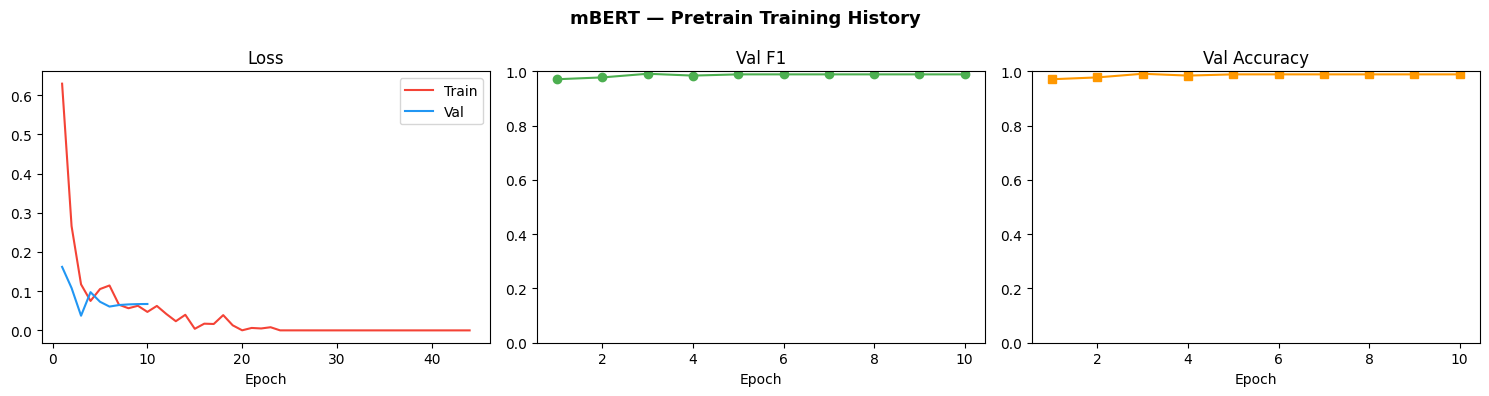

✅ Saved → ../results/figures/mBERT_Pretrain_history.png

--- mBERT Pretrain Test Results ---



  mBERT — Pretrain — Classification Report
              precision    recall  f1-score   support

     genuine       0.99      1.00      1.00       219
        fake       1.00      0.99      1.00       229

    accuracy                           1.00       448
   macro avg       1.00      1.00      1.00       448
weighted avg       1.00      1.00      1.00       448



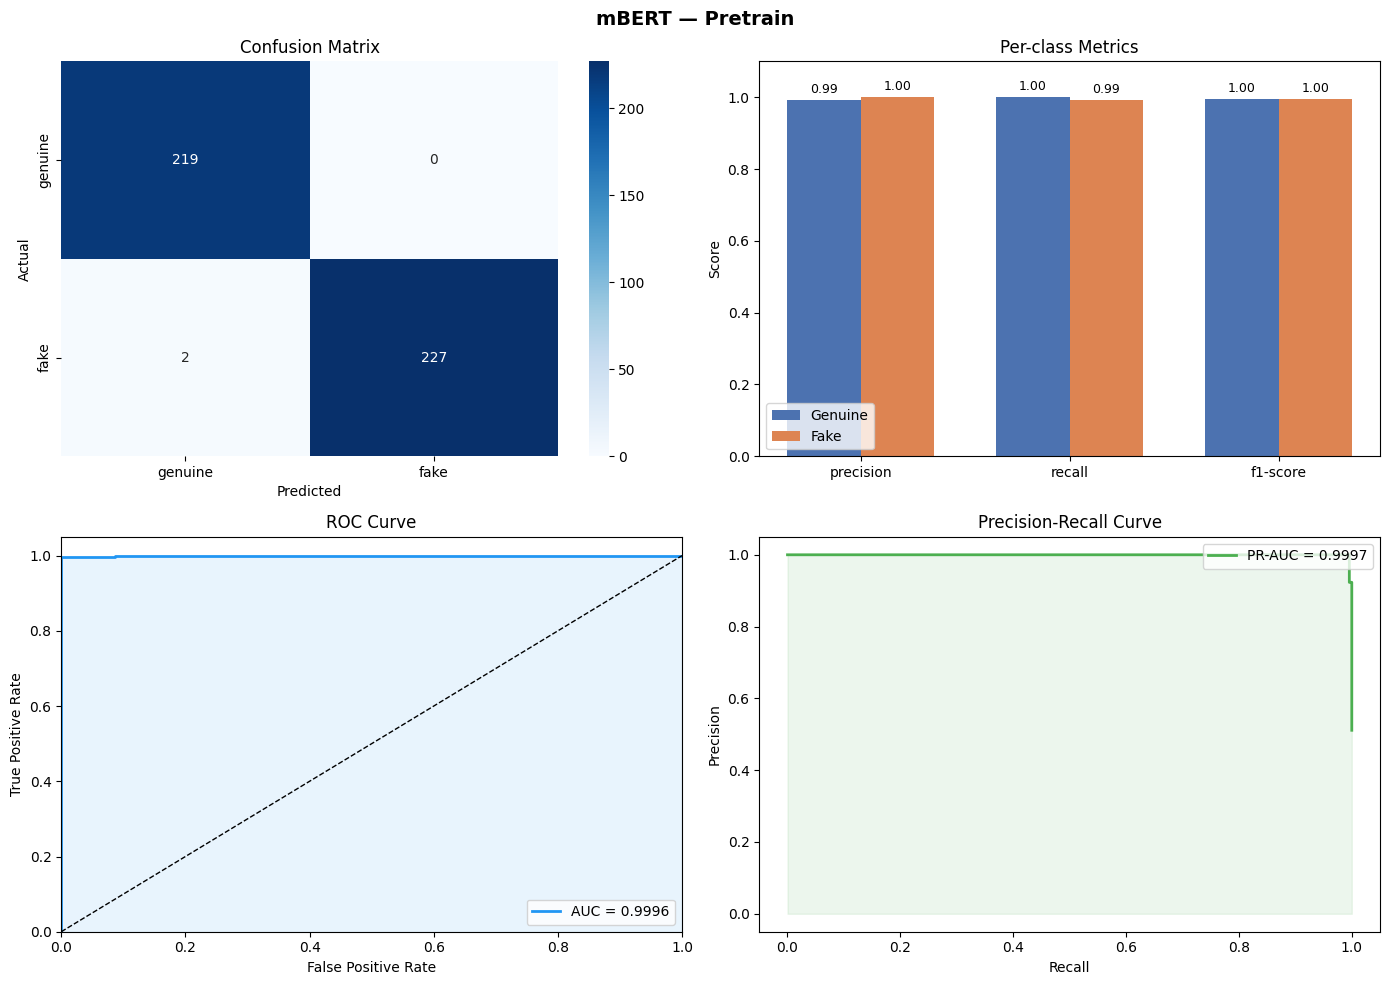

✅ Saved → ../results/figures/mBERT_Pretrain_evaluation.png

  Accuracy : 0.9955
  F1       : 0.9955
  ROC-AUC  : 0.9996

--- PHASE 2: FINETUNE (mBERT) ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 3934.22it/s]
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting finetuning...


Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.079358,0.077387,0.984126,0.984127
2,0.000597,0.079481,0.984126,0.984127
3,0.000135,0.020271,0.994709,0.994709
4,0.000084,0.100716,0.986772,0.986772
5,0.000083,0.084758,0.989418,0.989418


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.22s/it]


✅ Finetuned model saved → ../models/transformers/mBERT_finetuned


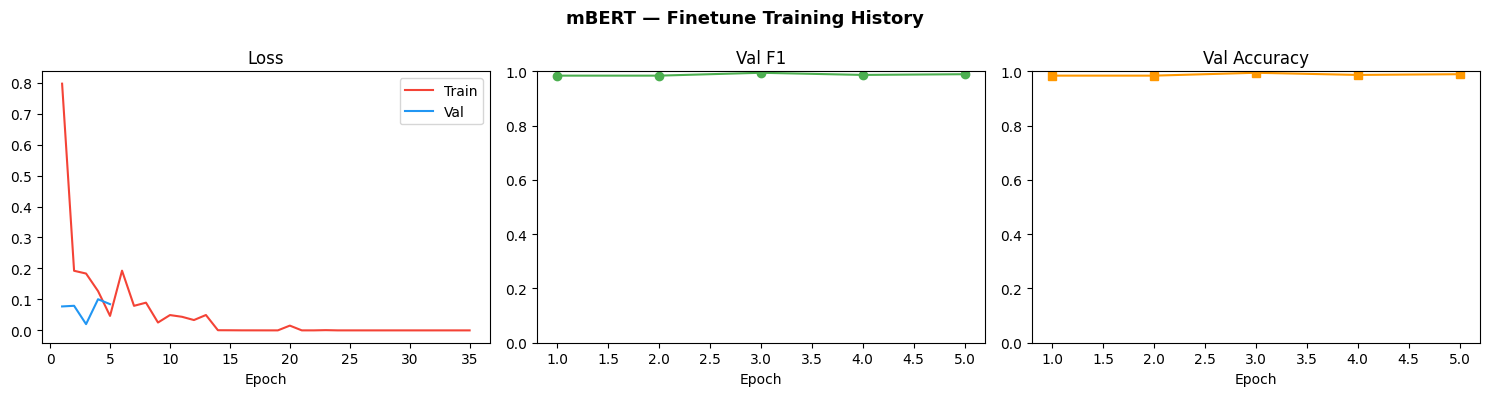

✅ Saved → ../results/figures/mBERT_Finetune_history.png

--- mBERT Finetune Test Results ---



  mBERT — Finetune — Classification Report
              precision    recall  f1-score   support

     genuine       1.00      0.97      0.99       191
        fake       0.97      1.00      0.99       187

    accuracy                           0.99       378
   macro avg       0.99      0.99      0.99       378
weighted avg       0.99      0.99      0.99       378



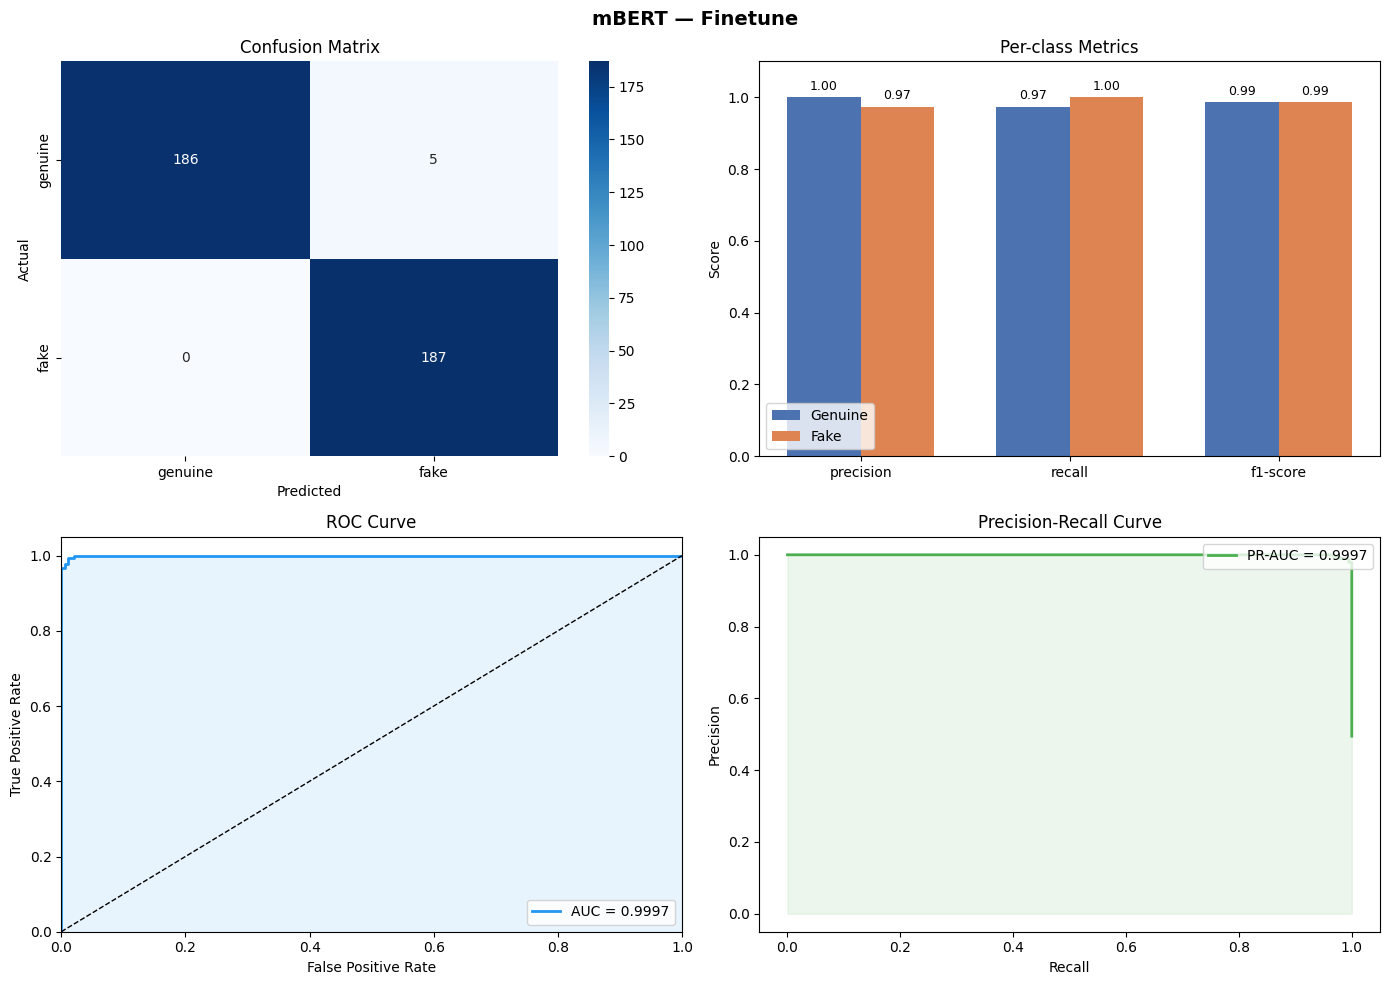

✅ Saved → ../results/figures/mBERT_Finetune_evaluation.png

  Accuracy : 0.9868
  F1       : 0.9868
  ROC-AUC  : 0.9997
🗑️  Deleted ../models/transformers/mBERT_pretrain_ckpt
🗑️  Deleted ../models/transformers/mBERT_finetune_ckpt
💾 Free disk : 9GB

✅ mBERT complete!

  MODEL : XLM_RoBERTa
  CKPT  : xlm-roberta-base

Tokenizing datasets...


Map: 100%|██████████████████████████████████████████████████████████████████| 378/378 [00:00<00:00, 7552.12 examples/s]


✅ Tokenization complete!

--- PHASE 1: PRETRAIN (XLM_RoBERTa) ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 2732.24it/s]
XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downst

Starting pretraining...


Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.200960,0.241793,0.952990,0.953020
2,0.125239,0.147386,0.973158,0.973154
3,0.084122,0.052988,0.988815,0.988814
4,0.045192,0.037137,0.993289,0.993289
5,0.009726,0.053329,0.993288,0.993289
6,0.034719,0.044715,0.993289,0.993289
7,0.025648,0.044591,0.993289,0.993289
8,0.012283,0.047748,0.993289,0.993289
9,0.000211,0.039377,0.995526,0.995526
10,0.000140,0.041218,0.995526,0.995526


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.29s/it]


✅ Pretrained model saved → ../models/transformers/XLM_RoBERTa_pretrained


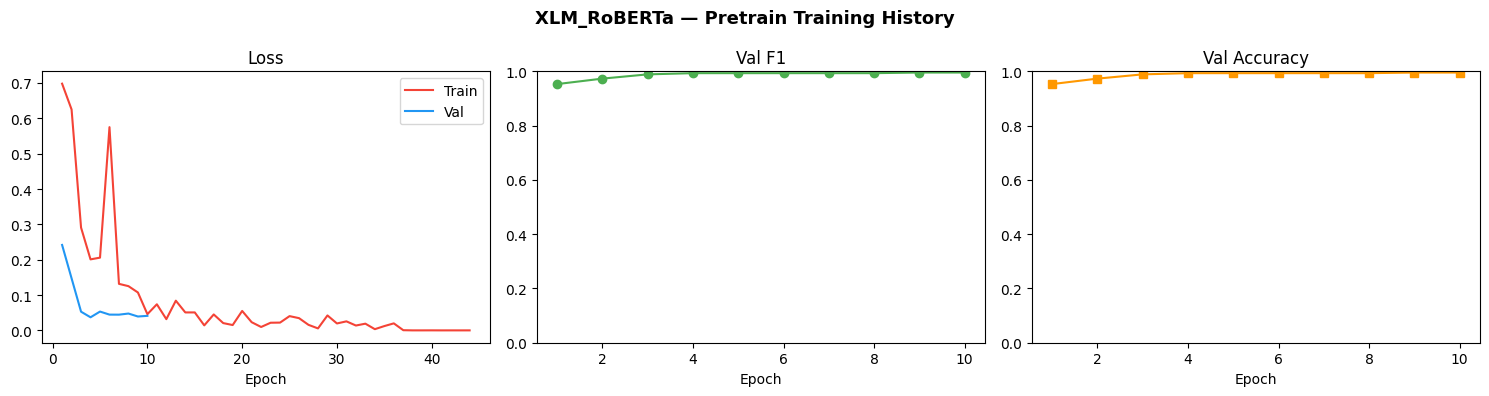

✅ Saved → ../results/figures/XLM_RoBERTa_Pretrain_history.png

--- XLM_RoBERTa Pretrain Test Results ---



  XLM_RoBERTa — Pretrain — Classification Report
              precision    recall  f1-score   support

     genuine       0.99      1.00      1.00       219
        fake       1.00      0.99      1.00       229

    accuracy                           1.00       448
   macro avg       1.00      1.00      1.00       448
weighted avg       1.00      1.00      1.00       448



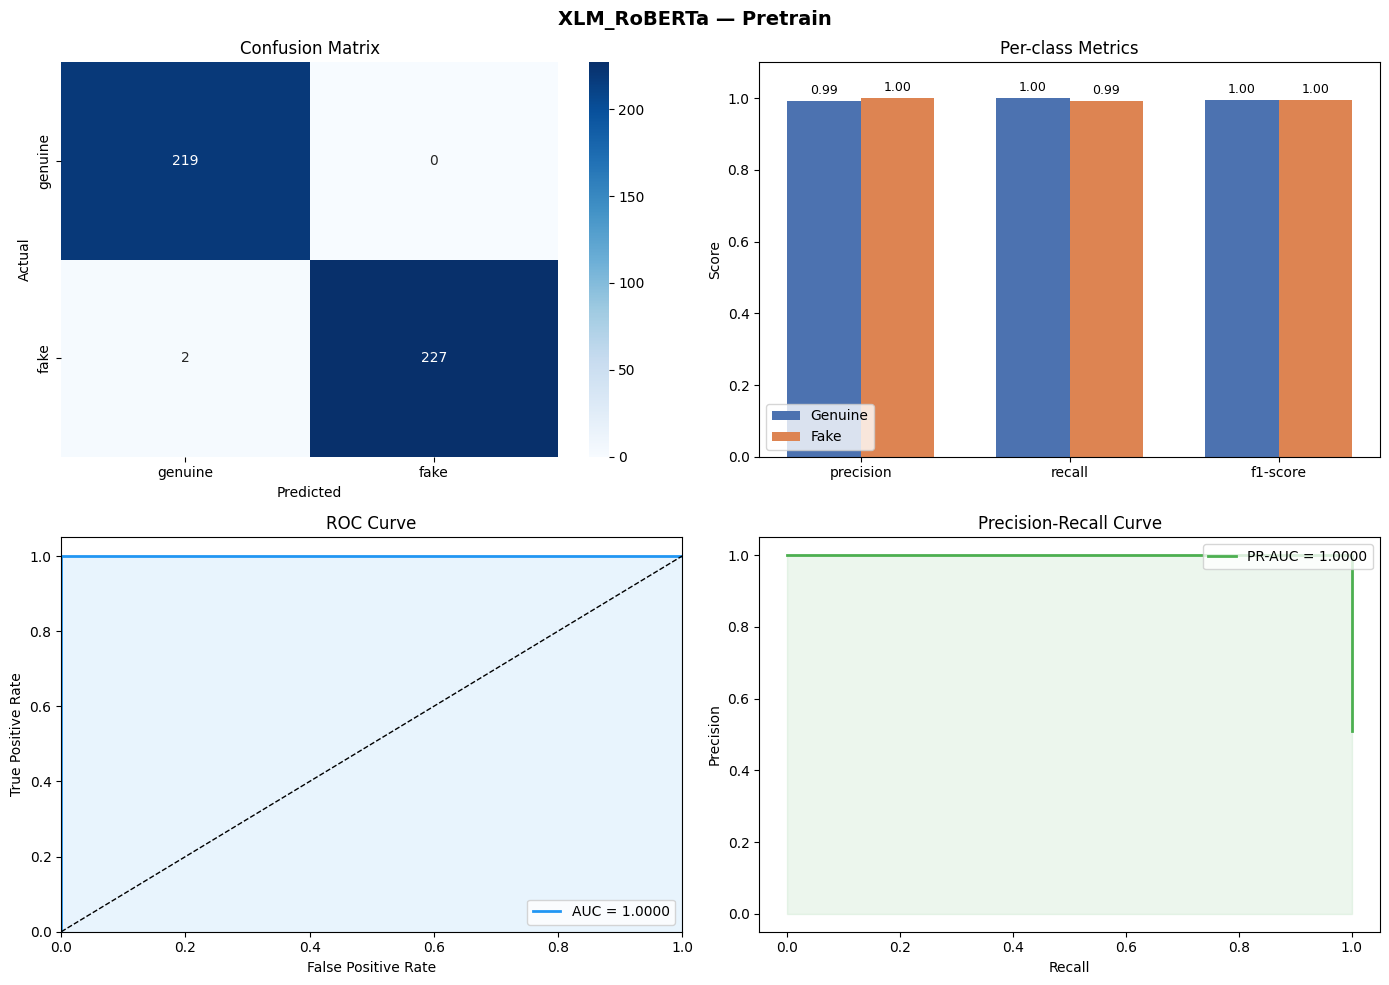

✅ Saved → ../results/figures/XLM_RoBERTa_Pretrain_evaluation.png

  Accuracy : 0.9955
  F1       : 0.9955
  ROC-AUC  : 1.0000

--- PHASE 2: FINETUNE (XLM_RoBERTa) ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 4493.13it/s]
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting finetuning...


Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.094327,0.223717,0.960285,0.960317
2,0.093663,0.084120,0.984127,0.984127
3,0.037399,0.081603,0.986768,0.986772
4,0.000226,0.147993,0.981481,0.981481
5,0.000173,0.103271,0.984127,0.984127


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.26s/it]


✅ Finetuned model saved → ../models/transformers/XLM_RoBERTa_finetuned


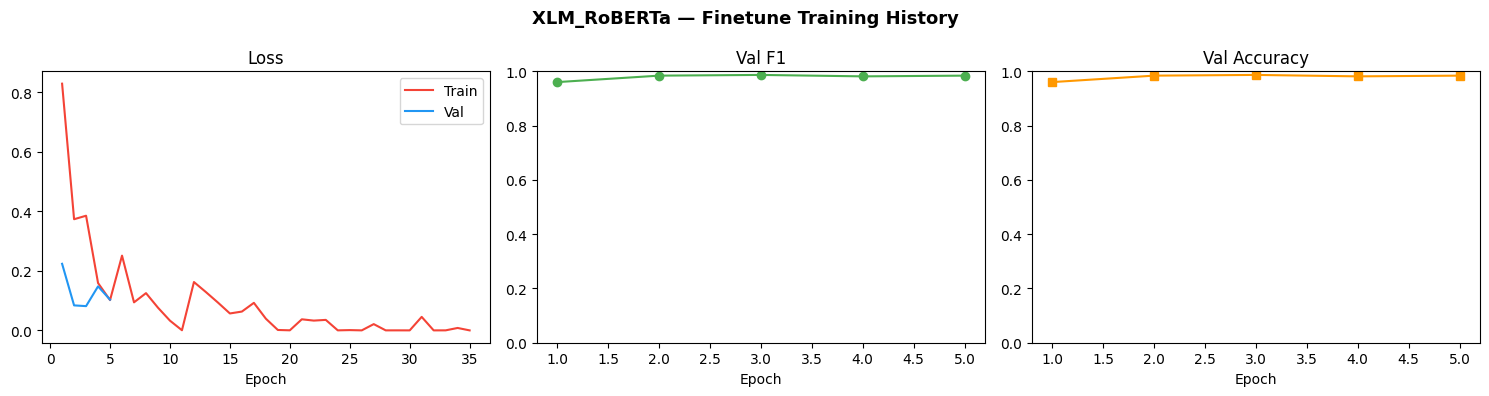

✅ Saved → ../results/figures/XLM_RoBERTa_Finetune_history.png

--- XLM_RoBERTa Finetune Test Results ---



  XLM_RoBERTa — Finetune — Classification Report
              precision    recall  f1-score   support

     genuine       0.99      0.98      0.99       191
        fake       0.98      0.99      0.99       187

    accuracy                           0.99       378
   macro avg       0.99      0.99      0.99       378
weighted avg       0.99      0.99      0.99       378



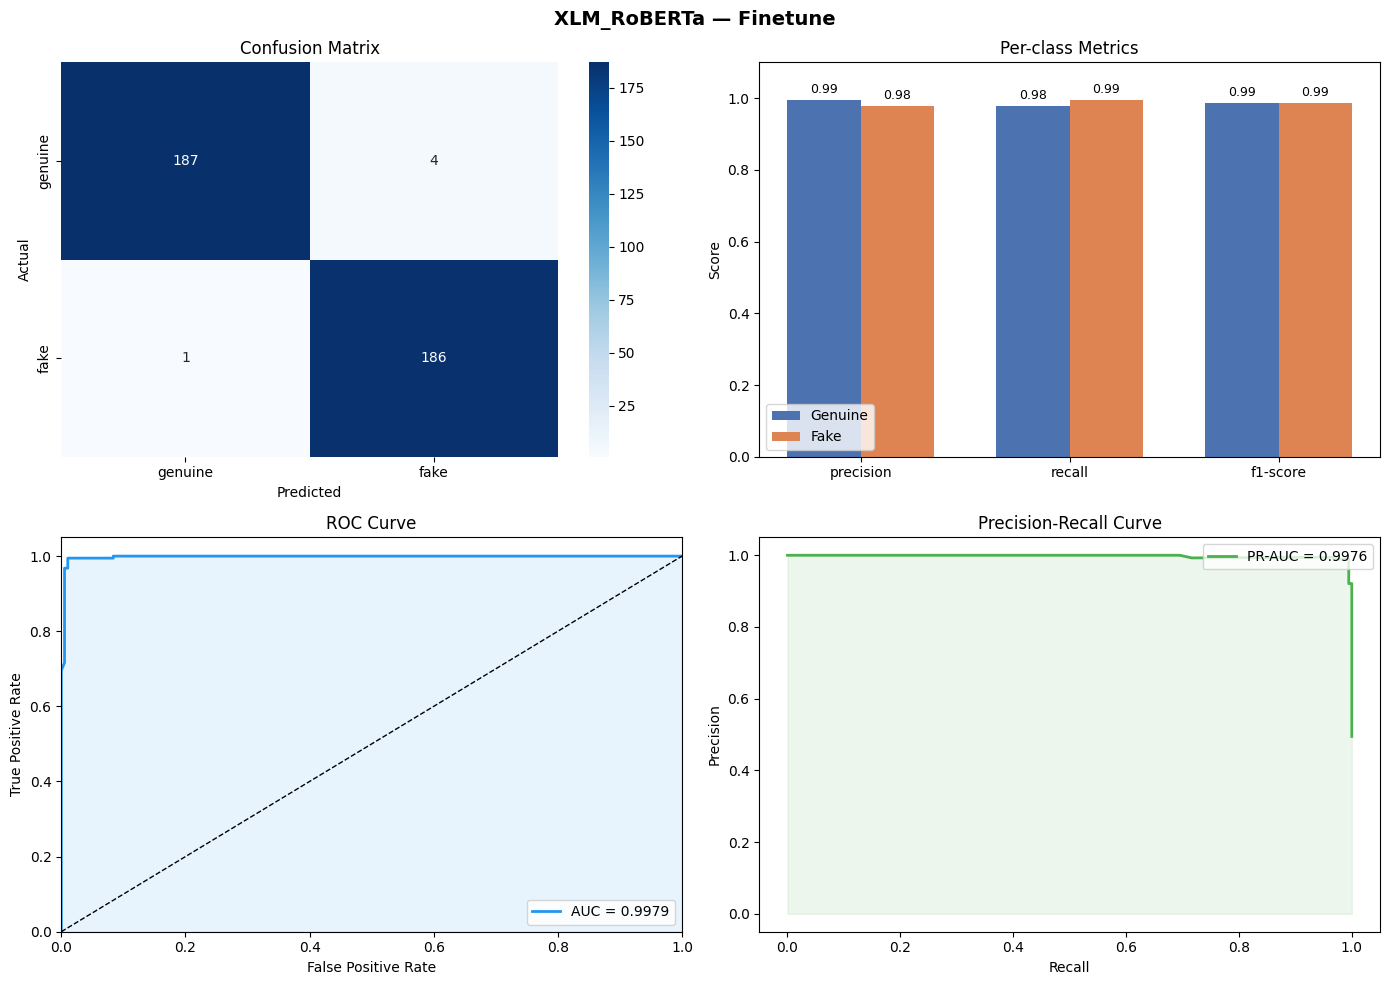

✅ Saved → ../results/figures/XLM_RoBERTa_Finetune_evaluation.png

  Accuracy : 0.9868
  F1       : 0.9868
  ROC-AUC  : 0.9979
🗑️  Deleted ../models/transformers/XLM_RoBERTa_pretrain_ckpt
🗑️  Deleted ../models/transformers/XLM_RoBERTa_finetune_ckpt
💾 Free disk : 3GB

✅ XLM_RoBERTa complete!


In [18]:
# ══════════════════════════════════════════════════════════════
# MAIN TRAINING LOOP
# ══════════════════════════════════════════════════════════════
for model_name, model_checkpoint in MODELS.items():
    print(f"\n{'='*55}")
    print(f"  MODEL : {model_name}")
    print(f"  CKPT  : {model_checkpoint}")
    print(f"{'='*55}")

    all_results[model_name] = {}

    # ── Create output dirs ────────────────────────────────────
    os.makedirs("../models/transformers", exist_ok=True)
    os.makedirs("../results/figures",     exist_ok=True)
    os.makedirs("../results/metrics",     exist_ok=True)
    os.makedirs(f"../results/logs/{model_name}_pretrain", exist_ok=True)
    os.makedirs(f"../results/logs/{model_name}_finetune", exist_ok=True)

    # ── Tokenizer ─────────────────────────────────────────────
    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

    def tokenize(batch):
        return tokenizer(
            batch["review_text"],
            truncation = True,
            padding    = "max_length",
            max_length = 128
        )

    # ── Tokenize datasets ─────────────────────────────────────
    print("\nTokenizing datasets...")
    syn_train_hf  = to_hf_dataset(syn_train).map(tokenize,  batched=True)
    syn_val_hf    = to_hf_dataset(syn_val).map(tokenize,    batched=True)
    syn_test_hf   = to_hf_dataset(syn_test).map(tokenize,   batched=True)
    real_train_hf = to_hf_dataset(real_train).map(tokenize, batched=True)
    real_val_hf   = to_hf_dataset(real_val).map(tokenize,   batched=True)
    real_test_hf  = to_hf_dataset(real_test).map(tokenize,  batched=True)
    print("✅ Tokenization complete!")

    # ══════════════════════════════════════════════════════════
    # PHASE 1 — PRETRAIN ON SYNTHETIC
    # ══════════════════════════════════════════════════════════
    print(f"\n--- PHASE 1: PRETRAIN ({model_name}) ---")

    pretrain_model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint, num_labels=2
    )

    pretrain_args = TrainingArguments(
        output_dir                  = f"../models/transformers/{model_name}_pretrain_ckpt",
        num_train_epochs            = 10,
        per_device_train_batch_size = 16,
        per_device_eval_batch_size  = 32,
        learning_rate               = 3e-5,
        weight_decay                = 0.01,
        eval_strategy               = "epoch",
        save_strategy               = "no",        # ← no mid saves
        load_best_model_at_end      = False,        # ← needs saves
        save_only_model             = True,         # ← skip optimizer
        metric_for_best_model       = "f1",
        greater_is_better           = True,
        logging_dir                 = f"../results/logs/{model_name}_pretrain",
        logging_steps               = 50,
        warmup_ratio                = 0.1,
        fp16                        = USE_GPU,
    )

    pretrain_trainer = Trainer(
        model           = pretrain_model,
        args            = pretrain_args,
        train_dataset   = syn_train_hf,
        eval_dataset    = syn_val_hf,
        compute_metrics = compute_metrics,
    )

    print("Starting pretraining...")
    pretrain_trainer.train()

    # Save pretrained model
    pretrain_save_path = f"../models/transformers/{model_name}_pretrained"
    pretrain_trainer.save_model(pretrain_save_path)
    tokenizer.save_pretrained(pretrain_save_path)
    print(f"✅ Pretrained model saved → {pretrain_save_path}")

    # Evaluate pretrain
    plot_training_history(
        pretrain_trainer.state.log_history,
        model_name, "Pretrain"
    )
    print(f"\n--- {model_name} Pretrain Test Results ---")
    pretrain_scores = evaluate_transformer(
        pretrain_trainer, syn_test_hf,
        model_name, "Pretrain"
    )
    all_results[model_name]["pretrain"] = pretrain_scores

    print(f"\n  Accuracy : {pretrain_scores['accuracy']:.4f}")
    print(f"  F1       : {pretrain_scores['f1']:.4f}")
    print(f"  ROC-AUC  : {pretrain_scores['roc_auc']:.4f}")

    # ── Cleanup pretrain memory ───────────────────────────────
    del pretrain_model, pretrain_trainer
    gc.collect()
    if USE_GPU:
        torch.cuda.empty_cache()

    # ══════════════════════════════════════════════════════════
    # PHASE 2 — FINETUNE ON REAL DATA
    # ══════════════════════════════════════════════════════════
    print(f"\n--- PHASE 2: FINETUNE ({model_name}) ---")

    # Load from pretrained checkpoint
    ft_model = AutoModelForSequenceClassification.from_pretrained(
        pretrain_save_path, num_labels=2
    )

    finetune_args = TrainingArguments(
        output_dir                  = f"../models/transformers/{model_name}_finetune_ckpt",
        num_train_epochs            = 5,
        per_device_train_batch_size = 8,
        per_device_eval_batch_size  = 16,
        learning_rate               = 2e-5,        # lower than pretrain
        weight_decay                = 0.01,
        eval_strategy               = "epoch",
        save_strategy               = "no",        # ← no mid saves
        load_best_model_at_end      = False,        # ← needs saves
        save_only_model             = True,         # ← skip optimizer
        metric_for_best_model       = "f1",
        greater_is_better           = True,
        logging_dir                 = f"../results/logs/{model_name}_finetune",
        logging_steps               = 20,
        warmup_ratio                = 0.1,
        fp16                        = USE_GPU,
    )

    ft_trainer = Trainer(
        model           = ft_model,
        args            = finetune_args,
        train_dataset   = real_train_hf,
        eval_dataset    = real_val_hf,
        compute_metrics = compute_metrics,
    )

    print("Starting finetuning...")
    ft_trainer.train()

    # Save finetuned model
    finetune_save_path = f"../models/transformers/{model_name}_finetuned"
    ft_trainer.save_model(finetune_save_path)
    tokenizer.save_pretrained(finetune_save_path)
    print(f"✅ Finetuned model saved → {finetune_save_path}")

    # Evaluate finetune
    plot_training_history(
        ft_trainer.state.log_history,
        model_name, "Finetune"
    )
    print(f"\n--- {model_name} Finetune Test Results ---")
    finetune_scores = evaluate_transformer(
        ft_trainer, real_test_hf,
        model_name, "Finetune"
    )
    all_results[model_name]["finetune"] = finetune_scores

    print(f"\n  Accuracy : {finetune_scores['accuracy']:.4f}")
    print(f"  F1       : {finetune_scores['f1']:.4f}")
    print(f"  ROC-AUC  : {finetune_scores['roc_auc']:.4f}")

    # ── Cleanup between models ────────────────────────────────
    del ft_model, ft_trainer
    cleanup(model_name)
    print(f"\n✅ {model_name} complete!") 

In [6]:
# ── Dataset helper ─────────────────────────────────────────────
def to_hf_dataset(df):
    return HFDataset.from_dict({
        "review_text": df["review_text"].tolist(),
        "label":       df["label"].tolist(),
        "word_count":  df["word_count"].tolist(),
        "rating":      df["rating"].tolist(),
        "slang_count": df["slang_count"].tolist(),
    })

train_hf = to_hf_dataset(syn_train).map(tokenize, batched=True)
val_hf   = to_hf_dataset(syn_val).map(tokenize,   batched=True)
test_hf  = to_hf_dataset(syn_test).map(tokenize,  batched=True)

Map: 100%|██████████████████████████████████████████████████████████████████| 448/448 [00:00<00:00, 7128.95 examples/s]


In [7]:
# ── Model ──────────────────────────────────────────────────────
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
)

# ── Metrics ────────────────────────────────────────────────────
f1_metric  = evaluate.load("f1")
acc_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds          = np.argmax(logits, axis=1)
    return {
        "f1":       f1_metric.compute(
                        predictions=preds, references=labels,
                        average="weighted")["f1"],
        "accuracy": acc_metric.compute(
                        predictions=preds, references=labels)["accuracy"],
    }

Loading weights: 100%|█████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 3972.67it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newl

In [8]:
# ── Early stopping callback ────────────────────────────────────
# Stops training if F1 doesn't improve for 3 consecutive eval epochs
early_stop = EarlyStoppingCallback(
    early_stopping_patience  = 3,
    early_stopping_threshold = 0.001   # minimum delta to count as improvement
)

In [9]:
# ── PRETRAIN on synthetic data ─────────────────────────────────
pretrain_args = TrainingArguments(
    output_dir              = "./pretrain_mbert_checkpoints",

    # ── Epochs & batch size ───────────────────────────────────
    num_train_epochs            = 10,
    per_device_train_batch_size = 16,   # reduce to 8 if OOM
    per_device_eval_batch_size  = 32,

    # ── Optimizer & scheduler ─────────────────────────────────
    learning_rate    = 2e-5,
    weight_decay     = 0.01,
    warmup_ratio     = 0.1,             # 10% of steps for warmup
    lr_scheduler_type= "cosine",        # cosine decay → better F1 than linear

    # ── Memory optimizations ──────────────────────────────────
    fp16                        = use_fp16,         # half-precision on GPU
    gradient_accumulation_steps = 2,                # effective batch = 16×2=32
    gradient_checkpointing      = True,             # trades compute for memory
    dataloader_pin_memory       = True,             # faster GPU data transfer
    dataloader_num_workers      = 4,                # parallel data loading

    # ── Evaluation & checkpointing ────────────────────────────
    eval_strategy     = "epoch",
    save_strategy           = "epoch",
    save_total_limit        = 3,        # keep only 3 best checkpoints on disk
    load_best_model_at_end  = True,
    metric_for_best_model   = "f1",
    greater_is_better       = True,

    # ── Logging ───────────────────────────────────────────────
    logging_dir             = "./logs",
    logging_steps           = 50,
    report_to               = "none",   # change to "wandb" if you use W&B
)

pretrain_trainer = Trainer(
    model           = model,
    args            = pretrain_args,
    train_dataset   = train_hf,
    eval_dataset    = val_hf,
    compute_metrics = compute_metrics,
    callbacks       = [early_stop],     # ← early stopping wired in
)

print("Starting pretraining on synthetic data...")
pretrain_trainer.train()
pretrain_trainer.save_model("../models/transformers/pretrained_mbert_model")
tokenizer.save_pretrained("../models/transformers/pretrained_mbert_model")  # save tokenizer alongside model
print("Pretraining complete. Model saved to ../models/transformers/pretrained_mbert_model\n")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting pretraining on synthetic data...


Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.378267,0.107265,0.970920,0.970917
2,0.134814,0.057637,0.986579,0.986577
3,0.083883,0.061203,0.984339,0.984340
4,0.044115,0.035772,0.993287,0.993289
5,0.015559,0.019365,0.995526,0.995526
6,0.000701,0.022013,0.995526,0.995526
7,0.002804,0.035705,0.995526,0.995526
8,0.001034,0.037048,0.995526,0.995526


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.14s/it]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.l

Pretraining complete. Model saved to ../models/transformers/pretrained_mbert_model



In [10]:
import json

transformer_results = {
    "mBERT": {
        "f1": 0.9955,
        "accuracy": 0.9955,
        "best_epoch": 5,
        "best_val_loss": 0.0194,
        "overfit_from_epoch": 6
    },
    "XLM-RoBERTa": {
        "f1": 0.9955,
        "accuracy": 0.9955,
        "best_epoch": 4,
        "best_val_loss": 0.0232,
        "overfit_from_epoch": 5
    },
}

with open("../results/metrics/transformer_results.json", "w") as f:
    json.dump(transformer_results, f, indent=2)

print("✅ Transformer results saved!")
print(json.dumps(transformer_results, indent=2))

✅ Transformer results saved!
{
  "mBERT": {
    "f1": 0.9955,
    "accuracy": 0.9955,
    "best_epoch": 5,
    "best_val_loss": 0.0194,
    "overfit_from_epoch": 6
  },
  "XLM-RoBERTa": {
    "f1": 0.9955,
    "accuracy": 0.9955,
    "best_epoch": 4,
    "best_val_loss": 0.0232,
    "overfit_from_epoch": 5
  }
}
